# 🎨 TCS34725 센서 데이터 기반 MLP 색깔 분류 - 학습

**목표**: RGB 센서(TCS34725)로 측정한 데이터를 사용하여 MLP 모델 학습

**데이터**: 색깔 6종 × 거리 4종 × 50회 측정 = 1200개 샘플

| 거리  | 샘플 수 | 비고         |
|-------|---------|--------------|
| 0.5cm | 50개    | 근거리 측정  |
| 1cm   | 50개    | 중거리 측정  |
| 2cm   | 50개    | 원거리 측정  |
| 5cm   | 50개    | 먼거리 측정  |

**색깔**: 6종 (라벨당 200개)
- 🔴 Red (빨강): 200개
- 🟠 Orange (주황): 200개
- 🟡 Yellow (노랑): 200개
- 🟢 Green (초록): 200개
- 🔵 Blue (파랑): 200개
- 🟣 Purple (보라): 200개

**모델**: PyTorch MLP (3 → 64 → 32 → 6)

In [2]:
# 필요한 라이브러리 import
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os

In [3]:
# 📂 데이터 로드
data_dir = "./color_data_distance"

# all_color_05to2.csv 우선 찾기
preferred_file = "all_color_05to2.csv"
if os.path.exists(f"{data_dir}/{preferred_file}"):
    csv_path = f"{data_dir}/{preferred_file}"
    print(f"📂 우선 파일 로드: {csv_path}")
else:
    # 병합된 파일 찾기 (all_로 시작하는 파일)
    all_files = [f for f in os.listdir(data_dir) if f.startswith('all_') and f.endswith('.csv')]
    
    if all_files:
        # 가장 최근 파일 사용
        latest_file = sorted(all_files)[-1]
        csv_path = f"{data_dir}/{latest_file}"
        print(f"📂 로드할 파일: {csv_path}")
    else:
        # 개별 파일들 병합
        files = [f for f in os.listdir(data_dir) if f.endswith('.csv')]
        all_data = []
        for f in files:
            temp_df = pd.read_csv(f"{data_dir}/{f}")
            all_data.append(temp_df)
        df = pd.concat(all_data, ignore_index=True)
        csv_path = None
        print(f"📂 {len(files)}개 파일 병합")

if csv_path:
    df = pd.read_csv(csv_path)

# 전체 데이터 로드 (비교용)
print("\n📂 전체 데이터 로드 중...")
all_files = [f for f in os.listdir(data_dir) if f.endswith('.csv')]
all_data = []
for f in all_files:
    temp_df = pd.read_csv(f"{data_dir}/{f}")
    all_data.append(temp_df)
df_all = pd.concat(all_data, ignore_index=True)
print(f"📂 전체 데이터: {len(df_all)}개 샘플")

print(f"\n총 샘플 수: {len(df)}개")
print(f"\n클래스별 분포:")
print(df['label'].value_counts())

if 'distance' in df.columns:
    print(f"\n거리별 분포:")
    print(df['distance'].value_counts())
    
    print(f"\n색깔 × 거리별 분포:")
    print(pd.crosstab(df['label'], df['distance']))

print(f"\n데이터 미리보기:")
df.head()

📂 우선 파일 로드: ./color_data_distance/all_color_05to2.csv

📂 전체 데이터 로드 중...
📂 전체 데이터: 3300개 샘플

총 샘플 수: 900개

클래스별 분포:
label
Blue      150
Green     150
Orange    150
Purple    150
Red       150
Yellow    150
Name: count, dtype: int64

거리별 분포:
distance
0.5cm    300
1cm      300
2cm      300
Name: count, dtype: int64

색깔 × 거리별 분포:
distance  0.5cm  1cm  2cm
label                    
Blue         50   50   50
Green        50   50   50
Orange       50   50   50
Purple       50   50   50
Red          50   50   50
Yellow       50   50   50

데이터 미리보기:


,R,G,B,label,distance
0,77,84,92,Blue,0.5cm
1,75,85,93,Blue,0.5cm
2,75,85,93,Blue,0.5cm
3,74,86,94,Blue,0.5cm
4,74,86,94,Blue,0.5cm


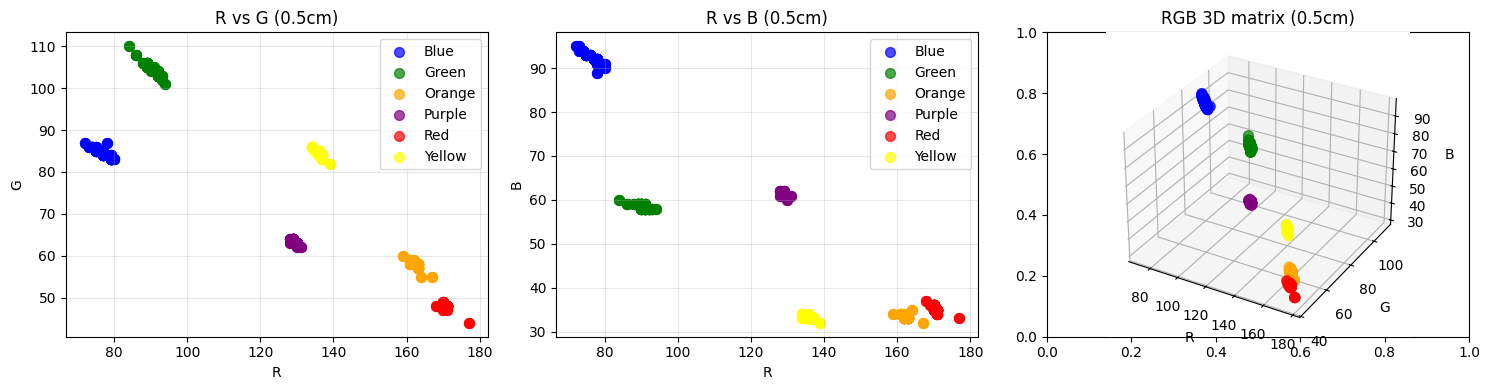

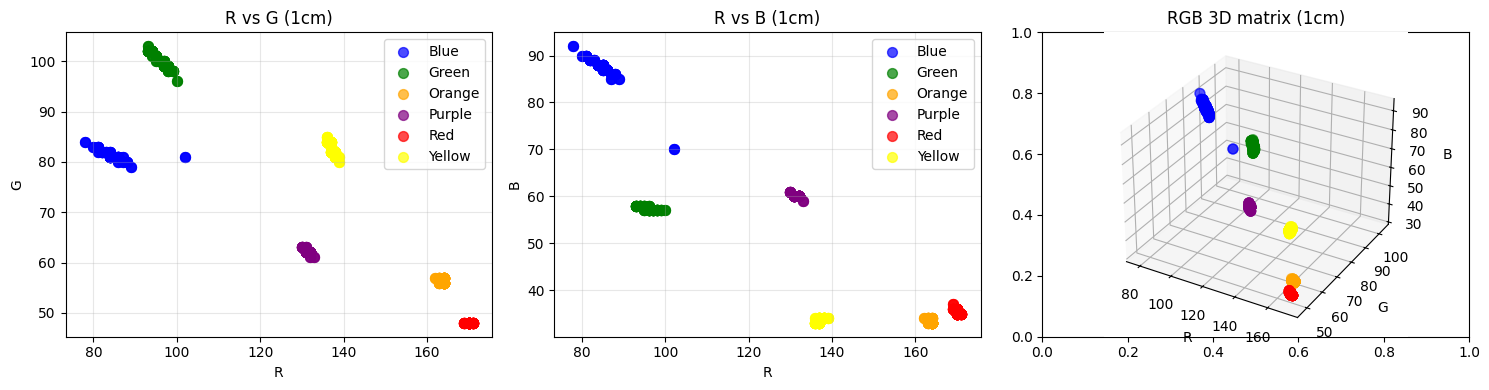

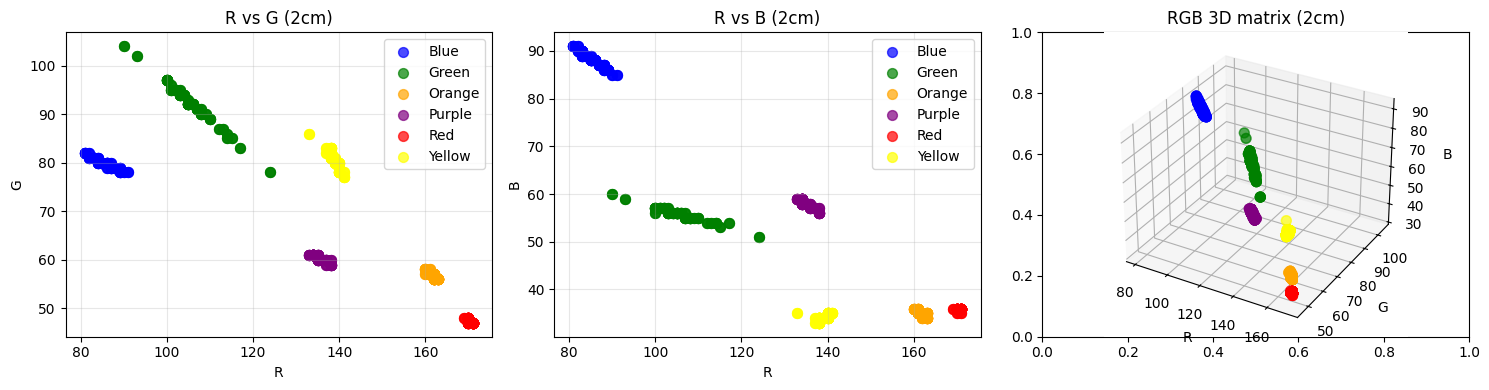

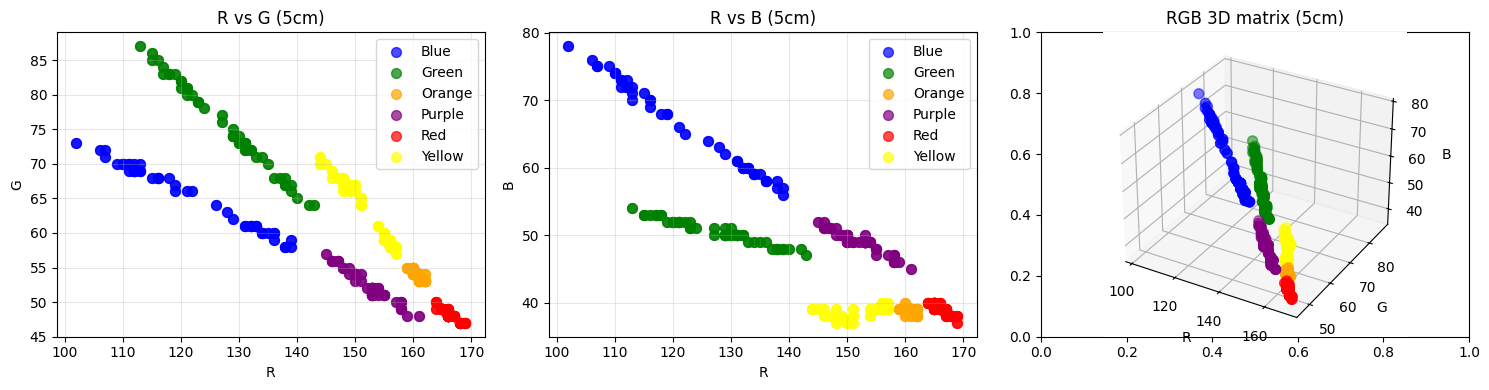


📊 전체 데이터 통합 시각화 (All Distances)


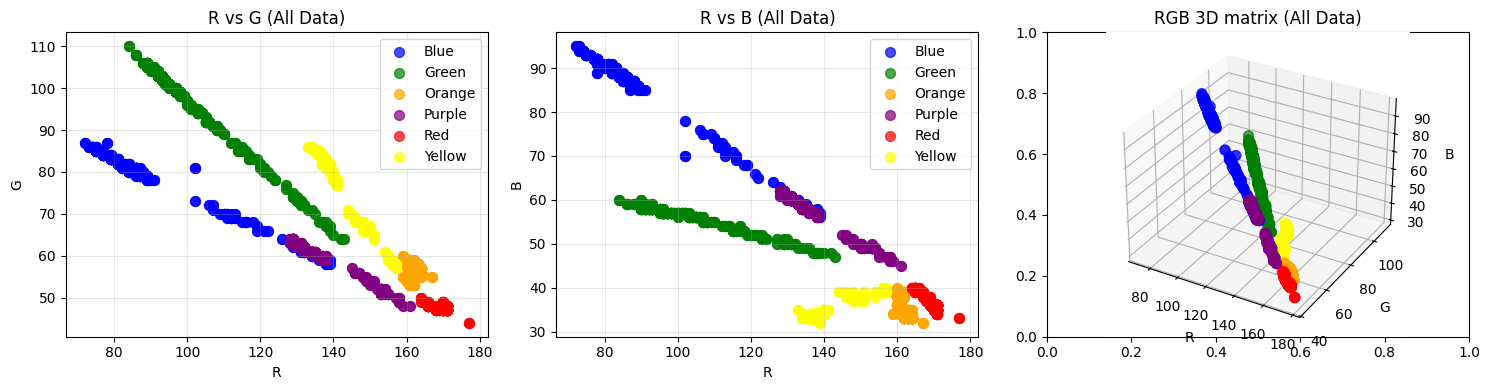


📊 0.5-2cm 데이터 시각화


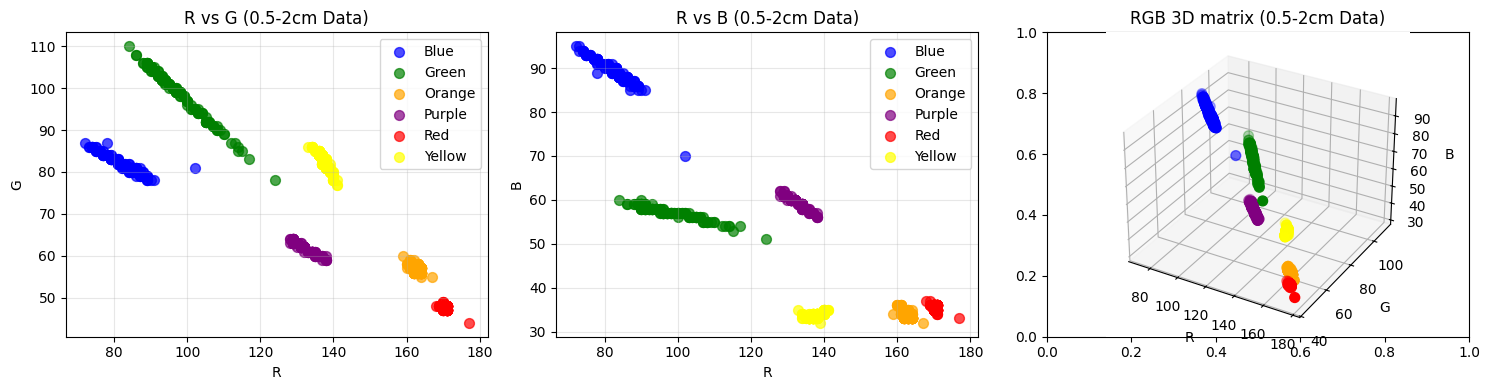


📊 거리별 RGB 통계:

[0.5cm] RGB 통계:
            R           G          B     
         mean  std   mean  std  mean  std
label                                    
Blue     76.8  2.1   84.5  1.2  92.2  1.3
Green    90.2  1.8  104.7  1.5  58.6  0.5
Orange  162.4  1.1   57.7  0.9  33.2  0.5
Purple  129.4  0.6   63.2  0.5  61.1  0.3
Red     170.5  1.1   47.9  0.6  35.2  0.7
Yellow  136.0  1.0   84.3  1.0  33.1  0.4

[1cm] RGB 통계:
            R           G          B     
         mean  std   mean  std  mean  std
label                                    
Blue     84.7  3.3   81.3  0.9  87.6  2.8
Green    96.0  1.8  100.1  1.5  57.4  0.5
Orange  163.8  0.4   56.5  0.5  33.2  0.4
Purple  131.5  0.7   62.1  0.4  60.1  0.3
Red     170.1  0.5   48.0  0.0  35.4  0.5
Yellow  137.2  0.8   82.7  1.2  33.6  0.5

[2cm] RGB 통계:
            R          G          B     
         mean  std  mean  std  mean  std
label                                   
Blue     85.3  2.5  80.0  1.1  88.2  1.6
Green   105.5  5.6

In [4]:
# 📈 데이터 분포 시각화 (거리별)
colors = {'Red': 'red', 'Orange': 'orange', 'Yellow': 'yellow', 'Green': 'green', 'Blue': 'blue', 'Purple': 'purple'}
DISTANCES = ['0.5cm', '1cm', '2cm', '5cm']

for dist in DISTANCES:
    dist_df = df_all[df_all['distance'] == dist]
    if len(dist_df) > 0:
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        
        # R vs G 산점도
        for label in dist_df['label'].unique():
            subset = dist_df[dist_df['label'] == label]
            axes[0].scatter(subset['R'], subset['G'], c=colors.get(label, 'gray'), label=label, s=50, alpha=0.7)
        axes[0].set_xlabel('R')
        axes[0].set_ylabel('G')
        axes[0].set_title(f'R vs G ({dist})')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # R vs B 산점도
        for label in dist_df['label'].unique():
            subset = dist_df[dist_df['label'] == label]
            axes[1].scatter(subset['R'], subset['B'], c=colors.get(label, 'gray'), label=label, s=50, alpha=0.7)
        axes[1].set_xlabel('R')
        axes[1].set_ylabel('B')
        axes[1].set_title(f'R vs B ({dist})')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        # 3D 산점도
        ax3d = fig.add_subplot(1, 3, 3, projection='3d')
        for label in dist_df['label'].unique():
            subset = dist_df[dist_df['label'] == label]
            ax3d.scatter(subset['R'], subset['G'], subset['B'], c=colors.get(label, 'gray'), label=label, s=50)
        ax3d.set_xlabel('R')
        ax3d.set_ylabel('G')
        ax3d.set_zlabel('B')
        ax3d.set_title(f'RGB 3D matrix ({dist})')
        
        plt.tight_layout()
        plt.show()

# 모든 데이터 통합 시각화
print("\n📊 전체 데이터 통합 시각화 (All Distances)")
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# R vs G 산점도
for label in df_all['label'].unique():
    subset = df_all[df_all['label'] == label]
    axes[0].scatter(subset['R'], subset['G'], c=colors.get(label, 'gray'), label=label, s=50, alpha=0.7)
axes[0].set_xlabel('R')
axes[0].set_ylabel('G')
axes[0].set_title('R vs G (All Data)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# R vs B 산점도
for label in df_all['label'].unique():
    subset = df_all[df_all['label'] == label]
    axes[1].scatter(subset['R'], subset['B'], c=colors.get(label, 'gray'), label=label, s=50, alpha=0.7)
axes[1].set_xlabel('R')
axes[1].set_ylabel('B')
axes[1].set_title('R vs B (All Data)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3D 산점도
ax3d = fig.add_subplot(1, 3, 3, projection='3d')
for label in df_all['label'].unique():
    subset = df_all[df_all['label'] == label]
    ax3d.scatter(subset['R'], subset['G'], subset['B'], c=colors.get(label, 'gray'), label=label, s=50)
ax3d.set_xlabel('R')
ax3d.set_ylabel('G')
ax3d.set_zlabel('B')
ax3d.set_title('RGB 3D matrix (All Data)')

plt.tight_layout()
plt.show()

# 0.5-2cm 데이터 시각화
print("\n📊 0.5-2cm 데이터 시각화")
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# R vs G 산점도
for label in df['label'].unique():
    subset = df[df['label'] == label]
    axes[0].scatter(subset['R'], subset['G'], c=colors.get(label, 'gray'), label=label, s=50, alpha=0.7)
axes[0].set_xlabel('R')
axes[0].set_ylabel('G')
axes[0].set_title('R vs G (0.5-2cm Data)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# R vs B 산점도
for label in df['label'].unique():
    subset = df[df['label'] == label]
    axes[1].scatter(subset['R'], subset['B'], c=colors.get(label, 'gray'), label=label, s=50, alpha=0.7)
axes[1].set_xlabel('R')
axes[1].set_ylabel('B')
axes[1].set_title('R vs B (0.5-2cm Data)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3D 산점도
ax3d = fig.add_subplot(1, 3, 3, projection='3d')
for label in df['label'].unique():
    subset = df[df['label'] == label]
    ax3d.scatter(subset['R'], subset['G'], subset['B'], c=colors.get(label, 'gray'), label=label, s=50)
ax3d.set_xlabel('R')
ax3d.set_ylabel('G')
ax3d.set_zlabel('B')
ax3d.set_title('RGB 3D matrix (0.5-2cm Data)')
plt.tight_layout()
plt.show()

# 통계 요약 (거리별)
print("\n📊 거리별 RGB 통계:")
for dist in DISTANCES:
    dist_df = df_all[df_all['distance'] == dist]
    if len(dist_df) > 0:
        print(f"\n[{dist}] RGB 통계:")
        print(dist_df.groupby('label')[['R', 'G', 'B']].agg(['mean', 'std']).round(1))

# 전체 통계 요약
print("\n📊 전체 RGB 통계:")
print(df_all.groupby('label')[['R', 'G', 'B']].agg(['mean', 'std']).round(1))

In [5]:
# 🔧 데이터 전처리
print("="*50)
print("Data Preprocessing")
print("="*50)

# Feature와 Label 분리
X = df[['R', 'G', 'B']].values.astype(np.float32)
y = df['label'].values

# Label Encoding
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"클래스: {le.classes_}")
print(f"인코딩: {dict(zip(le.classes_, range(len(le.classes_))))}")

# 정규화 (0-255 → 0-1)
X_norm = X / 255.0

# 표준화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_norm)

print(f"\nX shape: {X_scaled.shape}")
print(f"X mean: {X_scaled.mean(axis=0).round(4)}")
print(f"X std: {X_scaled.std(axis=0).round(4)}")

Data Preprocessing
클래스: ['Blue' 'Green' 'Orange' 'Purple' 'Red' 'Yellow']
인코딩: {'Blue': 0, 'Green': 1, 'Orange': 2, 'Purple': 3, 'Red': 4, 'Yellow': 5}

X shape: (900, 3)
X mean: [0. 0. 0.]
X std: [1. 1. 1.]


In [6]:
# 📊 Train/Validation/Test 분할 (70/20/10)
print("="*50)
print("Train/Validation/Test Split")
print("="*50)

# 먼저 전체 데이터를 train+val / test로 90/10 분할
X_temp, X_test, y_temp, y_test = train_test_split(
    X_scaled, y_encoded, 
    test_size=0.1,  # 10% test
    random_state=42, 
    stratify=y_encoded
)

# 그 다음 train+val을 train / val로 7:2 분할 (전체의 70/20)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=2/9,  # 2/(7+2) ≈ 0.222, 전체의 20%
    random_state=42,
    stratify=y_temp
)

print(f"Train: {X_train.shape[0]}개 ({X_train.shape[0]/len(X_scaled)*100:.0f}%)")
print(f"Validation: {X_val.shape[0]}개 ({X_val.shape[0]/len(X_scaled)*100:.0f}%)")
print(f"Test:  {X_test.shape[0]}개 ({X_test.shape[0]/len(X_scaled)*100:.0f}%)")
print(f"\nTrain 클래스 분포: {np.bincount(y_train)}")
print(f"Val 클래스 분포:  {np.bincount(y_val)}")
print(f"Test 클래스 분포:  {np.bincount(y_test)}")

# PyTorch 텐서로 변환
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.LongTensor(y_train)
X_val_tensor = torch.FloatTensor(X_val)
y_val_tensor = torch.LongTensor(y_val)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.LongTensor(y_test)

# DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

print("\n✓ DataLoader 생성 완료")

Train/Validation/Test Split
Train: 630개 (70%)
Validation: 180개 (20%)
Test:  90개 (10%)

Train 클래스 분포: [105 105 105 105 105 105]
Val 클래스 분포:  [30 30 30 30 30 30]
Test 클래스 분포:  [15 15 15 15 15 15]

✓ DataLoader 생성 완료


In [7]:
# 🧠 MLP 모델 정의
class ColorMLP(nn.Module):
    def __init__(self, input_dim=3, num_classes=6):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, num_classes)
        )
    
    def forward(self, x):
        return self.net(x)

# 모델 생성
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ColorMLP(input_dim=3, num_classes=6).to(device)

print(f"Device: {device}")
print(f"\n모델 구조:")
print(model)

# 파라미터 수 계산
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n총 파라미터: {total_params:,}")
print(f"학습 가능 파라미터: {trainable_params:,}")

Device: cuda

모델 구조:
ColorMLP(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=32, out_features=6, bias=True)
  )
)

총 파라미터: 2,534
학습 가능 파라미터: 2,534


In [8]:
# 🎯 모델 학습
print("="*50)
print("Training")
print("="*50)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.5)

num_epochs = 100
train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(num_epochs):
    # Training
    model.train()
    epoch_loss = 0
    correct = 0
    total = 0
    
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        _, predicted = outputs.max(1)
        total += y_batch.size(0)
        correct += predicted.eq(y_batch).sum().item()
    
    scheduler.step()
    
    avg_train_loss = epoch_loss / len(train_loader)
    train_accuracy = 100. * correct / total
    train_losses.append(avg_train_loss)
    train_accs.append(train_accuracy)
    
    # Validation
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            val_total += y_batch.size(0)
            val_correct += predicted.eq(y_batch).sum().item()
    
    avg_val_loss = val_loss / len(val_loader)
    val_accuracy = 100. * val_correct / val_total
    val_losses.append(avg_val_loss)
    val_accs.append(val_accuracy)
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch+1:3d}/{num_epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Train Acc: {train_accuracy:.1f}% | Val Acc: {val_accuracy:.1f}%")

print(f"\n✓ 학습 완료! 최종 Train Acc: {train_accs[-1]:.1f}% | Val Acc: {val_accs[-1]:.1f}%")

Training
Epoch [ 50/100] | Train Loss: 0.0004 | Val Loss: 0.0000 | Train Acc: 100.0% | Val Acc: 100.0%
Epoch [100/100] | Train Loss: 0.0009 | Val Loss: 0.0000 | Train Acc: 100.0% | Val Acc: 100.0%

✓ 학습 완료! 최종 Train Acc: 100.0% | Val Acc: 100.0%


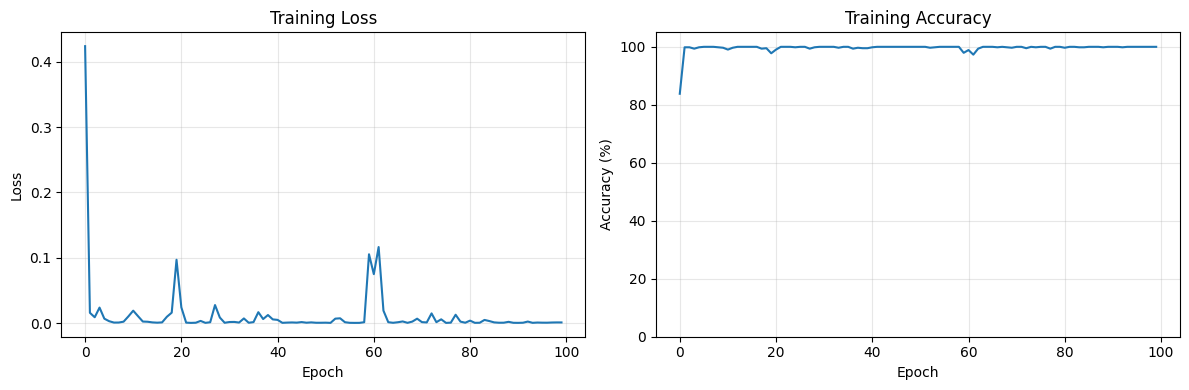

In [9]:
# 📈 학습 곡선 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(train_accs)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training Accuracy')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 105])

plt.tight_layout()
plt.show()

Test Evaluation
Test Accuracy: 100.00%

Confusion Matrix:
[[15  0  0  0  0  0]
 [ 0 15  0  0  0  0]
 [ 0  0 15  0  0  0]
 [ 0  0  0 15  0  0]
 [ 0  0  0  0 15  0]
 [ 0  0  0  0  0 15]]

Classification Report:
              precision    recall  f1-score   support

        Blue       1.00      1.00      1.00        15
       Green       1.00      1.00      1.00        15
      Orange       1.00      1.00      1.00        15
      Purple       1.00      1.00      1.00        15
         Red       1.00      1.00      1.00        15
      Yellow       1.00      1.00      1.00        15

    accuracy                           1.00        90
   macro avg       1.00      1.00      1.00        90
weighted avg       1.00      1.00      1.00        90



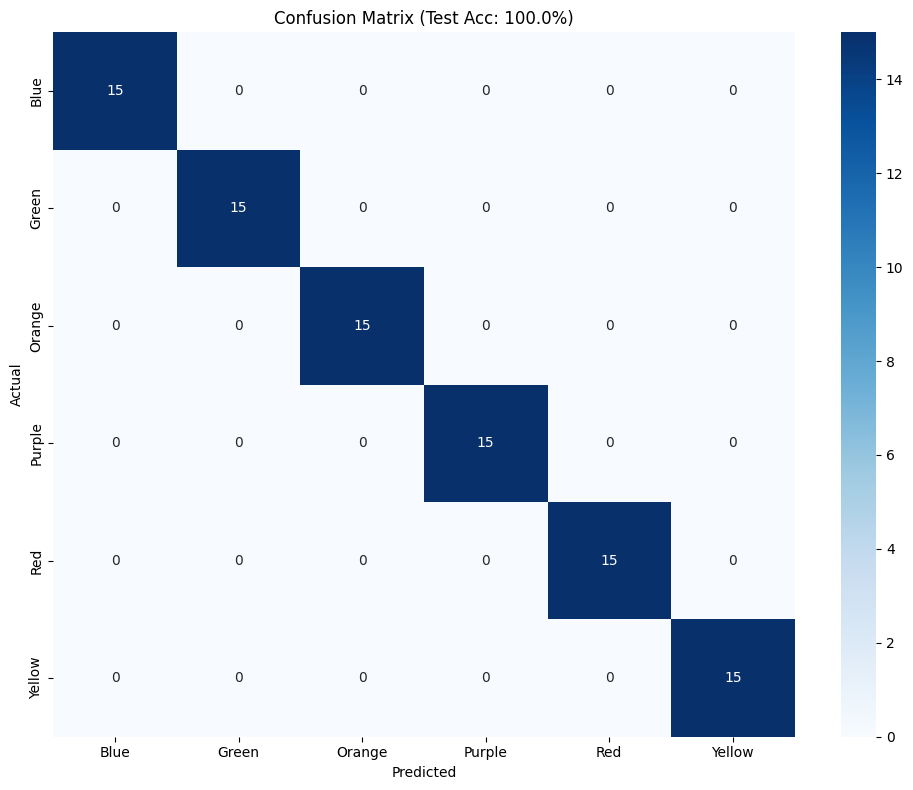

In [10]:
# 🧪 테스트 세트 평가
print("="*50)
print("Test Evaluation")
print("="*50)

model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y_batch.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# 정확도
test_acc = accuracy_score(all_labels, all_preds)
print(f"Test Accuracy: {test_acc:.2%}")

# 혼동 행렬
cm = confusion_matrix(all_labels, all_preds)
print(f"\nConfusion Matrix:")
print(cm)

# Classification Report
print(f"\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=le.classes_))

# 혼동 행렬 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix (Test Acc: {test_acc:.1%})')
plt.tight_layout()
plt.show()

In [12]:
# 📋 전체 데이터로 검증
print("="*50)
print(f"전체 데이터 검증 ({len(df)}개 샘플)")
print("="*50)

model.eval()
X_all = torch.FloatTensor(X_scaled).to(device)

with torch.no_grad():
    outputs = model(X_all)
    probs = torch.softmax(outputs, dim=1)
    _, predictions = outputs.max(1)

predictions = predictions.cpu().numpy()
probs = probs.cpu().numpy()

# 클래스별 정확도
correct_per_class = {}
total_per_class = {}

for i in range(len(df)):
    actual = le.classes_[y_encoded[i]]
    predicted = le.classes_[predictions[i]]
    
    if actual not in total_per_class:
        total_per_class[actual] = 0
        correct_per_class[actual] = 0
    
    total_per_class[actual] += 1
    if actual == predicted:
        correct_per_class[actual] += 1

emoji_map = {'Red': '🔴', 'Orange': '🟠', 'Yellow': '🟡', 
             'Green': '🟢', 'Blue': '🔵', 'Purple': '🟣'}

print("\n클래스별 정확도:")
total_correct = 0
for cls in le.classes_:
    if cls in total_per_class:
        acc = correct_per_class[cls] / total_per_class[cls]
        emoji = emoji_map.get(cls, '❓')
        print(f"  {emoji} {cls}: {correct_per_class[cls]}/{total_per_class[cls]} = {acc:.1%}")
        total_correct += correct_per_class[cls]

print(f"\n전체 정확도: {total_correct}/{len(df)} = {total_correct/len(df):.1%}")

전체 데이터 검증 (900개 샘플)

클래스별 정확도:
  🔵 Blue: 150/150 = 100.0%
  🟢 Green: 150/150 = 100.0%
  🟠 Orange: 150/150 = 100.0%
  🟣 Purple: 150/150 = 100.0%
  🔴 Red: 150/150 = 100.0%
  🟡 Yellow: 150/150 = 100.0%

전체 정확도: 900/900 = 100.0%


In [13]:
# 💾 모델 저장
print("="*50)
print("Model Saving")
print("="*50)

save_dir = "color_model_05to2"
os.makedirs(save_dir, exist_ok=True)

# 1. 모델 가중치 저장
torch.save(model.state_dict(), f"{save_dir}/color_mlp_weights.pth")

# 2. 전체 모델 저장
torch.save(model, f"{save_dir}/color_mlp_full.pth")

# 3. Scaler 저장
joblib.dump(scaler, f"{save_dir}/scaler.joblib")

# 4. LabelEncoder 저장
joblib.dump(le, f"{save_dir}/label_encoder.joblib")

# 5. 모델 정보 저장
model_info = {
    "input_dim": 3,
    "num_classes": 6,
    "class_names": list(le.classes_),
    "train_accuracy": train_accs[-1] / 100,
    "test_accuracy": test_acc,
    "num_samples": len(df),
    "scaler_mean": scaler.mean_.tolist(),
    "scaler_scale": scaler.scale_.tolist(),
    "architecture": "3 → 64 → 32 → 6",
}

with open(f"{save_dir}/model_info.json", "w") as f:
    json.dump(model_info, f, indent=2)

print(f"✓ 저장 완료: {save_dir}/")
for f in os.listdir(save_dir):
    size = os.path.getsize(f"{save_dir}/{f}") / 1024
    print(f"  - {f}: {size:.1f} KB")

Model Saving
✓ 저장 완료: color_model_05to2/
  - color_mlp_full.pth: 14.9 KB
  - color_mlp_weights.pth: 13.1 KB
  - label_encoder.joblib: 0.5 KB
  - model_info.json: 0.5 KB
  - scaler.joblib: 0.6 KB


In [14]:
# 🔮 추론 함수 정의
CLASS_NAMES = list(le.classes_)
EMOJI_MAP = {'Red': '🔴', 'Orange': '🟠', 'Yellow': '🟡', 
             'Green': '🟢', 'Blue': '🔵', 'Purple': '🟣'}

def classify_color(r, g, b):
    """
    RGB 값을 받아 딥러닝 모델로 색깔 분류
    
    Args:
        r, g, b: RGB 값 (0~255)
    
    Returns:
        tuple: (색깔 이름, 신뢰도, 모든 클래스 확률)
    """
    # 전처리
    x = np.array([[r, g, b]], dtype=np.float32) / 255.0
    x = scaler.transform(x)
    
    # 추론
    x_tensor = torch.FloatTensor(x).to(device)
    model.eval()
    with torch.no_grad():
        logits = model(x_tensor)
        probs = torch.softmax(logits, dim=1)
        pred_idx = logits.argmax(dim=1).item()
        confidence = probs[0, pred_idx].item()
    
    label = CLASS_NAMES[pred_idx]
    all_probs = {CLASS_NAMES[i]: probs[0, i].item() for i in range(len(CLASS_NAMES))}
    
    return label, confidence, all_probs

# 테스트
print("="*60)
print("🔮 추론 함수 테스트")
print("="*60)

# 각 색깔별 평균값으로 테스트
test_cases = df.groupby('label')[['R', 'G', 'B']].mean().round().astype(int)

print(f"\n{'RGB':^15} | {'예측':^12} | {'신뢰도':>8}")
print("-" * 45)
for label, row in test_cases.iterrows():
    r, g, b = row['R'], row['G'], row['B']
    pred_label, conf, probs = classify_color(r, g, b)
    emoji = EMOJI_MAP.get(pred_label, '❓')
    result = "✅" if pred_label == label else "❌"
    print(f"({r:3},{g:3},{b:3}) | {emoji} {pred_label:<10} | {conf:7.1%} {result}")

🔮 추론 함수 테스트

      RGB       |      예측      |      신뢰도
---------------------------------------------
( 82, 82, 89) | 🔵 Blue       |  100.0% ✅
( 97, 99, 57) | 🟢 Green      |  100.0% ✅
(163, 57, 34) | 🟠 Orange     |  100.0% ✅
(132, 62, 60) | 🟣 Purple     |  100.0% ✅
(170, 48, 36) | 🔴 Red        |  100.0% ✅
(137, 83, 34) | 🟡 Yellow     |  100.0% ✅


---
## 🚀 실시간 분류 (아두이노 연결)

In [ ]:
# 🔌 시리얼 통신 설정
import serial
import serial.tools.list_ports
import time
import re

# 포트 확인
print("사용 가능한 시리얼 포트:")
for port in serial.tools.list_ports.comports():
    print(f"  • {port.device}: {port.description}")

SERIAL_PORT = "COM3"  # 실제 포트로 변경
BAUD_RATE = 9600

In [ ]:
# RGB 데이터 파싱 함수
def parse_rgb_data(line):
    """
    다양한 형식의 RGB 데이터를 파싱
    """
    # 형식: "R : 값 G : 값 B : 값"
    pattern = r'R\s*:\s*(\d+)\s*G\s*:\s*(\d+)\s*B\s*:\s*(\d+)'
    match = re.search(pattern, line, re.IGNORECASE)
    if match:
        r, g, b = int(match.group(1)), int(match.group(2)), int(match.group(3))
        return r, g, b
    
    # 형식: "값,값,값"
    if ',' in line:
        parts = line.split(',')
        if len(parts) >= 3:
            try:
                r, g, b = float(parts[0]), float(parts[1]), float(parts[2])
                return int(r), int(g), int(b)
            except:
                pass
    
    return None

In [ ]:
#  실시간 분류 실행
def run_classification():
    """아두이노에서 RGB 값을 받아 실시간 분류"""
    
    try:
        ser = serial.Serial(SERIAL_PORT, BAUD_RATE, timeout=2)
        print(f"✓ 연결됨: {SERIAL_PORT} @ {BAUD_RATE} baud")
        print("="*60)
        print(" 사용법: 엔터를 누르면 RGB 1회 측정 후 분류합니다.")
        print(" 종료: 'q' 입력 후 엔터")
        print("="*60)
        
        time.sleep(2)
        ser.reset_input_buffer()
        count = 0
        
        while True:
            user_input = input("\n[엔터] 측정 시작 (q: 종료) > ").strip().lower()
            
            if user_input == 'q':
                print("\n 프로그램 종료")
                break
            
            ser.reset_input_buffer()
            print(" 측정 중...", end=" ", flush=True)
            
            measured = False
            for _ in range(10):
                if ser.in_waiting > 0:
                    line = ser.readline().decode('utf-8', errors='ignore').strip()
                    if line:
                        result = parse_rgb_data(line)
                        if result:
                            r, g, b = result
                            if 0 <= r <= 255 and 0 <= g <= 255 and 0 <= b <= 255:
                                label, conf, probs = classify_color(r, g, b)
                                count += 1
                                
                                emoji = EMOJI_MAP.get(label, '❓')
                                
                                print(f"\n{'='*60}")
                                print(f" 측정 결과 #{count}")
                                print(f"{'-'*60}")
                                print(f"  측정 RGB: ({r}, {g}, {b})")
                                print(f"{'-'*60}")
                                print(f"   분류 결과:  {label}")
                                print(f"   신뢰도: {conf:.1%}")
                                print(f"{'-'*60}")
                                print("  확률 분포:")
                                for color, prob in sorted(probs.items(), key=lambda x: -x[1]):
                                    bar = "█" * int(prob * 20)
                                    e = EMOJI_MAP.get(color, '❓')
                                    print(f"    {e} {color:10s} {bar} {prob:.1%}")
                                print(f"{'='*60}")
                                measured = True
                                break
                time.sleep(0.2)
            
            if not measured:
                print("\n⚠️ 데이터를 수신하지 못했습니다.")
                
    except serial.SerialException as e:
        print(f"✗ 연결 실패: {e}")
    except KeyboardInterrupt:
        print("\n\n⚠️ 사용자가 중단했습니다.")
    finally:
        if 'ser' in locals() and ser.is_open:
            ser.close()
            print(f"\n✓ 연결 종료 (총 {count}회 측정)")

# 실행
run_classification()

In [ ]:
# Green과 Orange 비교
print(df_all[df_all['label'].isin(['Green', 'Orange', 'Yellow'])].groupby('label')[['R','G','B']].describe())